# 🎬 Anime Intelligence: Data Analysis & Visualization using Python

## 📌 Overview
This project analyzes a dataset of top anime to find patterns in ratings, popularity, and genres.

## 🎯 Objectives
- Identify top-rated anime
- Analyze genre trends
- Understand score distribution
- Study score vs popularity

## IMPORT LIBRARIES

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## LOAD DATA

In [3]:
df = pd.read_csv(r"C:\Users\aayus\Desktop\top_anime_dataset.csv")

In [4]:
df.head()

,mal_id,title,title_english,type,source,episodes,status,airing,rating,score,scored_by,rank,popularity,members,favorites,synopsis,year,genres,studios,url
0,52991,Sousou no Frieren,Frieren: Beyond Journey's End,TV,Manga,28.0,Finished Airing,False,PG-13 - Teens 13 or older,9.28,823434,1.0,108,1353494,85889,During their decade-long quest to defeat the D...,2023.0,"Adventure, Drama, Fantasy",Madhouse,https://myanimelist.net/anime/52991/Sousou_no_...
1,59978,Sousou no Frieren 2nd Season,Frieren: Beyond Journey's End Season 2,TV,Manga,10.0,Currently Airing,True,PG-13 - Teens 13 or older,9.16,62148,2.0,644,414180,5476,"Following the First-Class Mage Exam, the trio—...",2026.0,"Adventure, Drama, Fantasy",Madhouse,https://myanimelist.net/anime/59978/Sousou_no_...
2,5114,Fullmetal Alchemist: Brotherhood,Fullmetal Alchemist: Brotherhood,TV,Manga,64.0,Finished Airing,False,R - 17+ (violence & profanity),9.11,2290193,3.0,3,3645704,240910,After a horrific alchemy experiment goes wrong...,2009.0,"Action, Adventure, Drama, Fantasy",Bones,https://myanimelist.net/anime/5114/Fullmetal_A...
3,57555,Chainsaw Man Movie: Reze-hen,Chainsaw Man – The Movie: Reze Arc,Movie,Manga,1.0,Finished Airing,False,R - 17+ (violence & profanity),9.09,255607,4.0,643,414906,12097,Despite the immediate challenges following bec...,NaN,"Action, Fantasy",MAPPA,https://myanimelist.net/anime/57555/Chainsaw_M...
4,9253,Steins;Gate,Steins;Gate,TV,Visual novel,24.0,Finished Airing,False,PG-13 - Teens 13 or older,9.07,1508032,5.0,14,2786505,201170,Eccentric scientist Rintarou Okabe has a never...,2011.0,"Drama, Sci-Fi, Suspense",White Fox,https://myanimelist.net/anime/9253/Steins_Gate


## CHECK DATA

In [5]:
df.shape

(500, 20)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   mal_id         500 non-null    int64  
 1   title          500 non-null    object 
 2   title_english  458 non-null    object 
 3   type           500 non-null    object 
 4   source         500 non-null    object 
 5   episodes       492 non-null    float64
 6   status         500 non-null    object 
 7   airing         500 non-null    bool   
 8   rating         500 non-null    object 
 9   score          500 non-null    float64
 10  scored_by      500 non-null    int64  
 11  rank           492 non-null    float64
 12  popularity     500 non-null    int64  
 13  members        500 non-null    int64  
 14  favorites      500 non-null    int64  
 15  synopsis       500 non-null    object 
 16  year           297 non-null    float64
 17  genres         494 non-null    object 
 18  studios   

## CLEAN DATA

In [7]:
df.isnull().sum()

mal_id             0
title              0
title_english     42
type               0
source             0
episodes           8
status             0
airing             0
rating             0
score              0
scored_by          0
rank               8
popularity         0
members            0
favorites          0
synopsis           0
year             203
genres             6
studios            2
url                0
dtype: int64

In [8]:
# Fill missing text columns
df['title_english'] = df['title_english'].fillna('Unknown')
df['genres'] = df['genres'].fillna('Unknown')
df['studios'] = df['studios'].fillna('Unknown')

In [9]:
# Fill numeric columns using median
df['episodes'] = df['episodes'].fillna(df['episodes'].median())
df['rank'] = df['rank'].fillna(df['rank'].median())
df['year'] = df['year'].fillna(df['year'].median())

## CHECK DUPLICATES

In [10]:
df.duplicated().sum()

np.int64(0)

# 📊 Exploratory Data Analysis (EDA)

In this section, we analyze the dataset to uncover patterns, trends, and insights using statistical summaries and visualizations.

In [11]:
df.describe()

,mal_id,episodes,score,scored_by,rank,popularity,members,favorites,year
count,500.000000,500.000000,500.000000,5.000000e+02,500.000000,500.000000,5.000000e+02,500.000000,500.000000
mean,30996.616000,18.256000,8.428940,3.271719e+05,246.552000,1559.430000,5.789175e+05,13815.252000,2015.854000
std,20276.672967,35.142003,0.222604,4.517006e+05,141.073182,1919.380637,6.924760e+05,29497.765969,7.001623
min,1.000000,1.000000,8.160000,9.190000e+02,1.000000,1.000000,2.212000e+03,24.000000,1970.000000
25%,10143.250000,1.000000,8.250000,4.857050e+04,125.750000,294.750000,1.133312e+05,852.000000,2015.000000
50%,35847.000000,12.000000,8.370000,1.519620e+05,246.500000,839.500000,3.296165e+05,3453.500000,2017.000000
75%,49393.500000,24.000000,8.562500,4.098580e+05,367.250000,2174.250000,7.721738e+05,13553.750000,2019.000000
max,63019.000000,500.000000,9.280000,3.038808e+06,494.000000,12270.000000,4.316356e+06,249284.000000,2026.000000


## 📈 Statistical Summary Insights

- Total anime analyzed: 500
- Average score is around 8.42 (indicates dataset contains highly rated anime)
- Most anime have 12 to 24 episodes
- Some anime have extremely high episode counts (outliers present)
- Popularity varies widely across anime
- Majority of anime are released after 2015

## 🏆 Top Anime Analysis

In [12]:
# Top by Score
top_score = df.sort_values(by='score', ascending=False).head(10)

In [13]:
top_score

,mal_id,title,title_english,type,source,episodes,status,airing,rating,score,scored_by,rank,popularity,members,favorites,synopsis,year,genres,studios,url
0,52991,Sousou no Frieren,Frieren: Beyond Journey's End,TV,Manga,28.0,Finished Airing,False,PG-13 - Teens 13 or older,9.28,823434,1.0,108,1353494,85889,During their decade-long quest to defeat the D...,2023.0,"Adventure, Drama, Fantasy",Madhouse,https://myanimelist.net/anime/52991/Sousou_no_...
1,59978,Sousou no Frieren 2nd Season,Frieren: Beyond Journey's End Season 2,TV,Manga,10.0,Currently Airing,True,PG-13 - Teens 13 or older,9.16,62148,2.0,644,414180,5476,"Following the First-Class Mage Exam, the trio—...",2026.0,"Adventure, Drama, Fantasy",Madhouse,https://myanimelist.net/anime/59978/Sousou_no_...
2,5114,Fullmetal Alchemist: Brotherhood,Fullmetal Alchemist: Brotherhood,TV,Manga,64.0,Finished Airing,False,R - 17+ (violence & profanity),9.11,2290193,3.0,3,3645704,240910,After a horrific alchemy experiment goes wrong...,2009.0,"Action, Adventure, Drama, Fantasy",Bones,https://myanimelist.net/anime/5114/Fullmetal_A...
3,57555,Chainsaw Man Movie: Reze-hen,Chainsaw Man – The Movie: Reze Arc,Movie,Manga,1.0,Finished Airing,False,R - 17+ (violence & profanity),9.09,255607,4.0,643,414906,12097,Despite the immediate challenges following bec...,2017.0,"Action, Fantasy",MAPPA,https://myanimelist.net/anime/57555/Chainsaw_M...
4,9253,Steins;Gate,Steins;Gate,TV,Visual novel,24.0,Finished Airing,False,PG-13 - Teens 13 or older,9.07,1508032,5.0,14,2786505,201170,Eccentric scientist Rintarou Okabe has a never...,2011.0,"Drama, Sci-Fi, Suspense",White Fox,https://myanimelist.net/anime/9253/Steins_Gate
5,38524,Shingeki no Kyojin Season 3 Part 2,Attack on Titan Season 3 Part 2,TV,Manga,10.0,Finished Airing,False,R - 17+ (violence & profanity),9.05,1772569,6.0,20,2560224,62801,Seeking to restore humanity's diminishing hope...,2019.0,"Action, Drama, Suspense",Wit Studio,https://myanimelist.net/anime/38524/Shingeki_n...
6,28977,Gintama°,Gintama Season 4,TV,Manga,51.0,Finished Airing,False,PG-13 - Teens 13 or older,9.05,270734,8.0,348,686377,17445,"Gintoki, Shinpachi, and Kagura return as the f...",2015.0,"Action, Comedy, Sci-Fi",Bandai Namco Pictures,https://myanimelist.net/anime/28977/Gintama°
7,39486,Gintama: The Final,Gintama: The Very Final,Movie,Manga,1.0,Finished Airing,False,PG-13 - Teens 13 or older,9.05,85590,7.0,1513,180815,4638,Two years have passed following the Tendoshuu'...,2017.0,"Action, Comedy, Drama, Sci-Fi",Bandai Namco Pictures,https://myanimelist.net/anime/39486/Gintama__T...
8,11061,Hunter x Hunter (2011),Hunter x Hunter,TV,Manga,148.0,Finished Airing,False,PG-13 - Teens 13 or older,9.03,1957682,9.0,8,3151639,227808,Hunters devote themselves to accomplishing haz...,2011.0,"Action, Adventure, Fantasy",Madhouse,https://myanimelist.net/anime/11061/Hunter_x_H...
9,60022,One Piece Fan Letter,Unknown,TV Special,Light novel,1.0,Finished Airing,False,PG-13 - Teens 13 or older,9.02,105906,13.0,1788,146484,2538,Although the golden age of piracy is about to ...,2017.0,"Action, Adventure, Fantasy",Toei Animation,https://myanimelist.net/anime/60022/One_Piece_...


In [14]:
# Top by Members
top_popular = df.sort_values(by='members', ascending=False).head(10)

In [15]:
top_popular

,mal_id,title,title_english,type,source,episodes,status,airing,rating,score,scored_by,rank,popularity,members,favorites,synopsis,year,genres,studios,url
122,16498,Shingeki no Kyojin,Attack on Titan,TV,Manga,25.0,Finished Airing,False,R - 17+ (violence & profanity),8.57,3038808,121.0,1,4316356,187384,"Centuries ago, mankind was slaughtered to near...",2013.0,"Action, Award Winning, Drama, Suspense",Wit Studio,https://myanimelist.net/anime/16498/Shingeki_n...
98,1535,Death Note,Death Note,TV,Manga,37.0,Finished Airing,False,R - 17+ (violence & profanity),8.62,2977869,97.0,2,4255809,184714,"Brutal murders, petty thefts, and senseless vi...",2006.0,"Supernatural, Suspense",Madhouse,https://myanimelist.net/anime/1535/Death_Note
2,5114,Fullmetal Alchemist: Brotherhood,Fullmetal Alchemist: Brotherhood,TV,Manga,64.0,Finished Airing,False,R - 17+ (violence & profanity),9.11,2290193,3.0,3,3645704,240910,After a horrific alchemy experiment goes wrong...,2009.0,"Action, Adventure, Drama, Fantasy",Bones,https://myanimelist.net/anime/5114/Fullmetal_A...
173,30276,One Punch Man,One-Punch Man,TV,Web manga,12.0,Finished Airing,False,R - 17+ (violence & profanity),8.48,2405629,171.0,4,3491486,66358,The seemingly unimpressive Saitama has a rathe...,2015.0,"Action, Comedy",Madhouse,https://myanimelist.net/anime/30276/One_Punch_Man
223,38000,Kimetsu no Yaiba,Demon Slayer: Kimetsu no Yaiba,TV,Manga,26.0,Finished Airing,False,R - 17+ (violence & profanity),8.41,2339211,221.0,5,3407810,94601,"Ever since the death of his father, the burden...",2019.0,"Action, Award Winning, Supernatural",ufotable,https://myanimelist.net/anime/38000/Kimetsu_no...
8,11061,Hunter x Hunter (2011),Hunter x Hunter,TV,Manga,148.0,Finished Airing,False,PG-13 - Teens 13 or older,9.03,1957682,9.0,8,3151639,227808,Hunters devote themselves to accomplishing haz...,2011.0,"Action, Adventure, Fantasy",Madhouse,https://myanimelist.net/anime/11061/Hunter_x_H...
32,32281,Kimi no Na wa.,Your Name.,Movie,Original,1.0,Finished Airing,False,PG-13 - Teens 13 or older,8.83,2065939,33.0,11,2999028,95056,"Mitsuha Miyamizu, a high school girl, yearns t...",2017.0,"Award Winning, Drama",CoMix Wave Films,https://myanimelist.net/anime/32281/Kimi_no_Na_wa
142,25777,Shingeki no Kyojin Season 2,Attack on Titan Season 2,TV,Manga,12.0,Finished Airing,False,R - 17+ (violence & profanity),8.54,2045334,142.0,12,2989308,22967,"For centuries, humanity has been hunted by gia...",2017.0,"Action, Drama, Suspense",Wit Studio,https://myanimelist.net/anime/25777/Shingeki_n...
160,40748,Jujutsu Kaisen,Jujutsu Kaisen,TV,Manga,24.0,Finished Airing,False,R - 17+ (violence & profanity),8.51,1965238,155.0,13,2982056,95486,Idly indulging in baseless paranormal activiti...,2020.0,"Action, Award Winning, Supernatural",MAPPA,https://myanimelist.net/anime/40748/Jujutsu_Ka...
4,9253,Steins;Gate,Steins;Gate,TV,Visual novel,24.0,Finished Airing,False,PG-13 - Teens 13 or older,9.07,1508032,5.0,14,2786505,201170,Eccentric scientist Rintarou Okabe has a never...,2011.0,"Drama, Sci-Fi, Suspense",White Fox,https://myanimelist.net/anime/9253/Steins_Gate


In [16]:
# Top by Favorites
top_fav = df.sort_values(by='favorites', ascending=False).head(10)

In [17]:
top_fav

,mal_id,title,title_english,type,source,episodes,status,airing,rating,score,scored_by,rank,popularity,members,favorites,synopsis,year,genres,studios,url
51,21,One Piece,One Piece,TV,Manga,12.0,Currently Airing,True,PG-13 - Teens 13 or older,8.73,1508303,52.0,17,2643713,249284,Barely surviving in a barrel after passing thr...,1999.0,"Action, Adventure, Fantasy",Toei Animation,https://myanimelist.net/anime/21/One_Piece
2,5114,Fullmetal Alchemist: Brotherhood,Fullmetal Alchemist: Brotherhood,TV,Manga,64.0,Finished Airing,False,R - 17+ (violence & profanity),9.11,2290193,3.0,3,3645704,240910,After a horrific alchemy experiment goes wrong...,2009.0,"Action, Adventure, Drama, Fantasy",Bones,https://myanimelist.net/anime/5114/Fullmetal_A...
8,11061,Hunter x Hunter (2011),Hunter x Hunter,TV,Manga,148.0,Finished Airing,False,PG-13 - Teens 13 or older,9.03,1957682,9.0,8,3151639,227808,Hunters devote themselves to accomplishing haz...,2011.0,"Action, Adventure, Fantasy",Madhouse,https://myanimelist.net/anime/11061/Hunter_x_H...
4,9253,Steins;Gate,Steins;Gate,TV,Visual novel,24.0,Finished Airing,False,PG-13 - Teens 13 or older,9.07,1508032,5.0,14,2786505,201170,Eccentric scientist Rintarou Okabe has a never...,2011.0,"Drama, Sci-Fi, Suspense",White Fox,https://myanimelist.net/anime/9253/Steins_Gate
122,16498,Shingeki no Kyojin,Attack on Titan,TV,Manga,25.0,Finished Airing,False,R - 17+ (violence & profanity),8.57,3038808,121.0,1,4316356,187384,"Centuries ago, mankind was slaughtered to near...",2013.0,"Action, Award Winning, Drama, Suspense",Wit Studio,https://myanimelist.net/anime/16498/Shingeki_n...
98,1535,Death Note,Death Note,TV,Manga,37.0,Finished Airing,False,R - 17+ (violence & profanity),8.62,2977869,97.0,2,4255809,184714,"Brutal murders, petty thefts, and senseless vi...",2006.0,"Supernatural, Suspense",Madhouse,https://myanimelist.net/anime/1535/Death_Note
337,1735,Naruto: Shippuuden,Naruto Shippuden,TV,Manga,500.0,Finished Airing,False,PG-13 - Teens 13 or older,8.29,1807221,321.0,15,2721147,119705,It has been two and a half years since Naruto ...,2007.0,"Action, Adventure, Fantasy",Studio Pierrot,https://myanimelist.net/anime/1735/Naruto__Shi...
252,30,Shinseiki Evangelion,Neon Genesis Evangelion,TV,Original,26.0,Finished Airing,False,PG-13 - Teens 13 or older,8.37,1201625,248.0,45,2007001,116733,Fifteen years after a cataclysmic event known ...,1995.0,"Avant Garde, Award Winning, Drama, Sci-Fi, Sus...","Gainax, Tatsunoko Production",https://myanimelist.net/anime/30/Shinseiki_Eva...
57,1575,Code Geass: Hangyaku no Lelouch,Code Geass: Lelouch of the Rebellion,TV,Original,25.0,Finished Airing,False,R - 17+ (violence & profanity),8.71,1510181,58.0,22,2448711,116405,"In the year 2010, the Holy Empire of Britannia...",2006.0,"Award Winning, Drama, Sci-Fi",Sunrise,https://myanimelist.net/anime/1575/Code_Geass_...
160,40748,Jujutsu Kaisen,Jujutsu Kaisen,TV,Manga,24.0,Finished Airing,False,R - 17+ (violence & profanity),8.51,1965238,155.0,13,2982056,95486,Idly indulging in baseless paranormal activiti...,2020.0,"Action, Award Winning, Supernatural",MAPPA,https://myanimelist.net/anime/40748/Jujutsu_Ka...


## 🏆 Top Anime Comparison Insights
- There is no single best anime, but based on analysis:
 - Frieren is the highest rated
 - Attack on Titan is the most popular
 - One Piece is the most loved
 - Fullmetal Alchemist: Brotherhood stands out as the best overall as it performs strongly across all metrics

## Genre Analysis

In [18]:
# splitting 
df['genres'] = df['genres'].str.split(', ')

In [19]:
# making copies
genre_df = df.explode('genres')

In [20]:
# counts
genre_df['genres'].value_counts()

genres
Action           184
Drama            183
Adventure        123
Fantasy          111
Comedy           110
Supernatural      81
Romance           78
Sci-Fi            76
Mystery           73
Suspense          55
Award Winning     46
Sports            45
Slice of Life     34
Horror             9
Unknown            6
Boys Love          5
Ecchi              4
Avant Garde        3
Gourmet            1
Name: count, dtype: int64

In [21]:
# BEST GENRES
genre_df.groupby('genres')['score'].mean()

genres
Action           8.454348
Adventure        8.417154
Avant Garde      8.496667
Award Winning    8.465435
Boys Love        8.308000
Comedy           8.415091
Drama            8.472732
Ecchi            8.382500
Fantasy          8.400811
Gourmet          8.590000
Horror           8.344444
Mystery          8.427123
Romance          8.362821
Sci-Fi           8.480132
Slice of Life    8.420882
Sports           8.402889
Supernatural     8.454074
Suspense         8.471273
Unknown          8.370000
Name: score, dtype: float64

## 🎭 Genre-Based Insights

- Gourmet genre has the highest average rating
- Drama, Sci-Fi, and Suspense genres perform consistently well
- Some genres like Horror and Boys Love have slightly lower average scores
- Genre plays a role in determining anime ratings

## 📅 Year Analysis

In [22]:
# Count anime per year
year_count = df['year'].value_counts().sort_index()

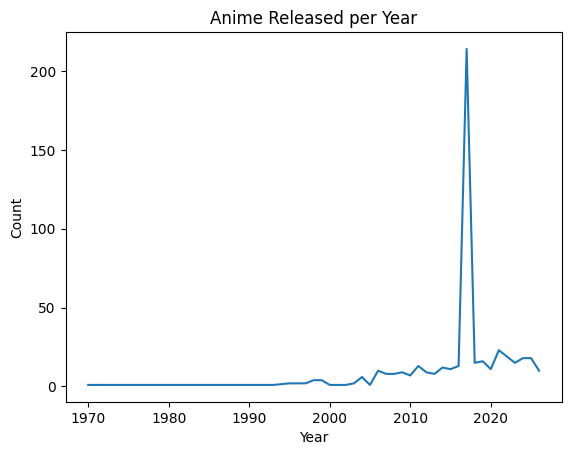

In [23]:
plt.figure()
sns.lineplot(x=year_count.index, y=year_count.values)
plt.title("Anime Released per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

In [24]:
# Average score per year
year_score = df.groupby('year')['score'].mean()
year_score

year
1970.0    8.360000
1979.0    8.350000
1980.0    8.780000
1986.0    8.200000
1989.0    8.210000
1990.0    8.280000
1992.0    8.460000
1993.0    8.550000
1995.0    8.340000
1996.0    8.225000
1997.0    8.420000
1998.0    8.377500
1999.0    8.507500
2000.0    8.780000
2002.0    8.420000
2003.0    8.260000
2004.0    8.430000
2005.0    8.650000
2006.0    8.398000
2007.0    8.321250
2008.0    8.440000
2009.0    8.463333
2010.0    8.311429
2011.0    8.487692
2012.0    8.475556
2013.0    8.396250
2014.0    8.420833
2015.0    8.415455
2016.0    8.413846
2017.0    8.414393
2018.0    8.484000
2019.0    8.429375
2020.0    8.443636
2021.0    8.410435
2022.0    8.514211
2023.0    8.504667
2024.0    8.455000
2025.0    8.446667
2026.0    8.491000
Name: score, dtype: float64

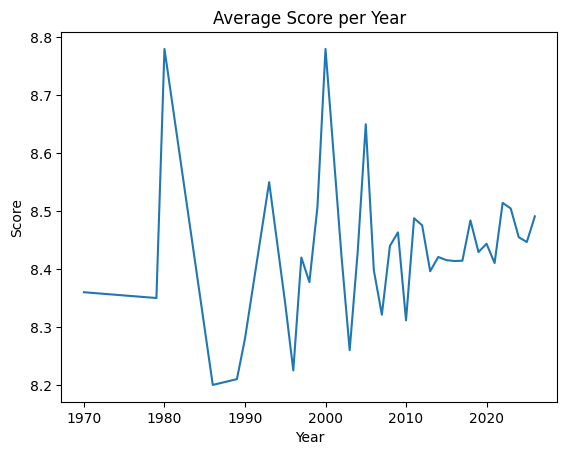

In [25]:
plt.figure()
sns.lineplot(x=year_score.index, y=year_score.values)
plt.title("Average Score per Year")
plt.xlabel("Year")
plt.ylabel("Score")
plt.show()

In [ ]:
## 📅 Year Insights

- Anime releases have increased over time
- A noticeable spike in one year suggests dataset concentration rather than actual trend
- Average anime scores remain stable across years
- No major improvement or decline in anime quality observed

## Type analysis

In [26]:
df['type'].value_counts()

type
TV            297
Movie         114
ONA            44
OVA            17
TV Special     11
Special         9
Music           7
PV              1
Name: count, dtype: int64

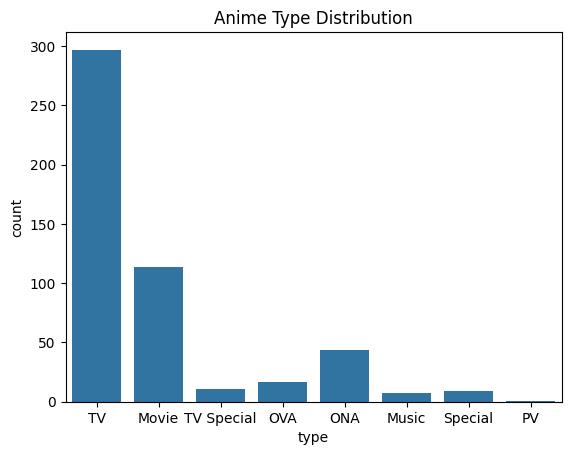

In [27]:
plt.figure()
sns.countplot(x='type', data=df)
plt.title("Anime Type Distribution")
plt.show()

## 📺 Type Insights

- Most anime are TV series
- Movies and other formats are less common
- TV format dominates the anime industry

## RATING ANALYSIS

In [28]:
df['rating'].value_counts()

rating
PG-13 - Teens 13 or older         313
R - 17+ (violence & profanity)    148
R+ - Mild Nudity                   18
G - All Ages                       14
PG - Children                       7
Name: count, dtype: int64

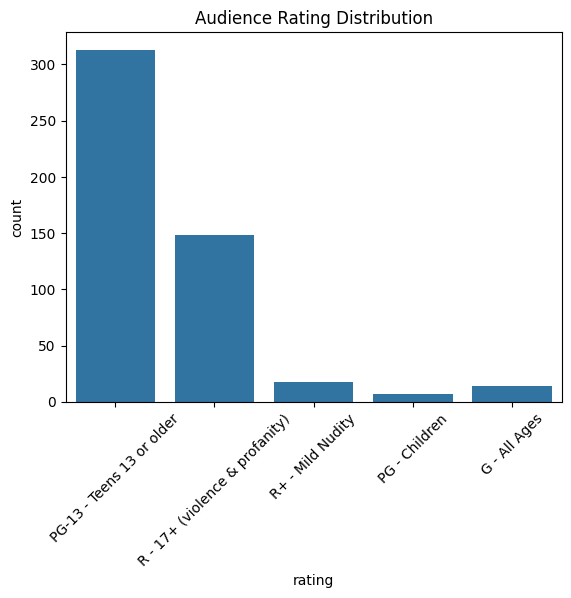

In [29]:
plt.figure()
sns.countplot(x='rating', data=df)
plt.xticks(rotation=45)
plt.title("Audience Rating Distribution")
plt.show()

## 🎯 Rating Insights

- Most anime fall under PG-13 category
- Some anime are for mature audiences (R-17+)
- Anime is mostly targeted at teens and young adults

## EPISODES vs SCORE

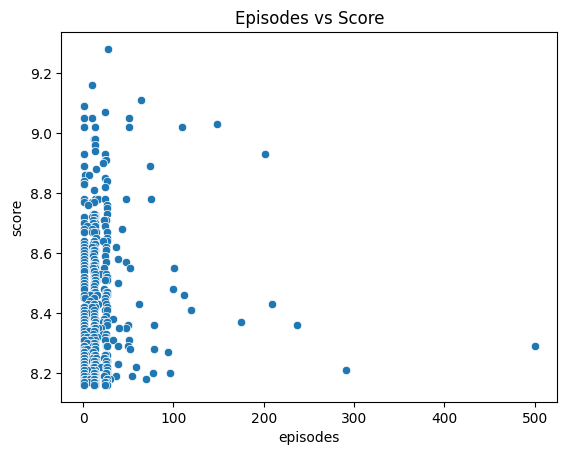

In [31]:
plt.figure()
sns.scatterplot(x='episodes', y='score', data=df)

plt.title("Episodes vs Score")
plt.show()

## FEATURE ENGINEERING

## Popularity category

In [33]:
df['popularity_category'] = df['members'].apply(lambda x: 'High' if x > 500000 else 'Medium' if x > 100000 else 'Low')

## Episode category

In [36]:
df['episode_category'] = df['episodes'].apply(lambda x: 'Short' if x <= 12 else 'Medium' if x <= 50 else 'Long')

## Engagement score

In [37]:
df['engagement_score'] = df['favorites'] / df['members']

In [38]:
df[['popularity_category', 'episode_category', 'engagement_score']].head()

,popularity_category,episode_category,engagement_score
0,High,Medium,0.063457
1,Medium,Short,0.013221
2,High,Long,0.066081
3,Medium,Short,0.029156
4,High,Medium,0.072194


In [41]:
df.head()

,mal_id,title,title_english,type,source,episodes,status,airing,rating,score,...,members,favorites,synopsis,year,genres,studios,url,popularity_category,episode_category,engagement_score
0,52991,Sousou no Frieren,Frieren: Beyond Journey's End,TV,Manga,28.0,Finished Airing,False,PG-13 - Teens 13 or older,9.28,...,1353494,85889,During their decade-long quest to defeat the D...,2023.0,"[Adventure, Drama, Fantasy]",Madhouse,https://myanimelist.net/anime/52991/Sousou_no_...,High,Medium,0.063457
1,59978,Sousou no Frieren 2nd Season,Frieren: Beyond Journey's End Season 2,TV,Manga,10.0,Currently Airing,True,PG-13 - Teens 13 or older,9.16,...,414180,5476,"Following the First-Class Mage Exam, the trio—...",2026.0,"[Adventure, Drama, Fantasy]",Madhouse,https://myanimelist.net/anime/59978/Sousou_no_...,Medium,Short,0.013221
2,5114,Fullmetal Alchemist: Brotherhood,Fullmetal Alchemist: Brotherhood,TV,Manga,64.0,Finished Airing,False,R - 17+ (violence & profanity),9.11,...,3645704,240910,After a horrific alchemy experiment goes wrong...,2009.0,"[Action, Adventure, Drama, Fantasy]",Bones,https://myanimelist.net/anime/5114/Fullmetal_A...,High,Long,0.066081
3,57555,Chainsaw Man Movie: Reze-hen,Chainsaw Man – The Movie: Reze Arc,Movie,Manga,1.0,Finished Airing,False,R - 17+ (violence & profanity),9.09,...,414906,12097,Despite the immediate challenges following bec...,2017.0,"[Action, Fantasy]",MAPPA,https://myanimelist.net/anime/57555/Chainsaw_M...,Medium,Short,0.029156
4,9253,Steins;Gate,Steins;Gate,TV,Visual novel,24.0,Finished Airing,False,PG-13 - Teens 13 or older,9.07,...,2786505,201170,Eccentric scientist Rintarou Okabe has a never...,2011.0,"[Drama, Sci-Fi, Suspense]",White Fox,https://myanimelist.net/anime/9253/Steins_Gate,High,Medium,0.072194


In [39]:
# ANALYZE POPULARITY CATEGORY
df.groupby('popularity_category')['score'].mean()

popularity_category
High      8.481818
Low       8.369561
Medium    8.413266
Name: score, dtype: float64

In [40]:
# ANALYZE EPISODE CATEGORY
df.groupby('episode_category')['score'].mean()

episode_category
Long      8.512414
Medium    8.440806
Short     8.412702
Name: score, dtype: float64

## Insights

- High popularity anime are watched by many people
- Short and medium anime are more common
- Long anime are fewer
- More episodes does not mean better anime
- Engagement score shows how much people love the anime
- Some anime are popular, but not everyone loves them
- Some anime are less popular but highly loved by fans

## 📌 Project Summary

In this project, I analyzed a dataset of top anime to understand patterns in ratings, popularity, genres, and audience engagement. 
I performed data cleaning, exploratory data analysis, and feature engineering to extract meaningful insights. 
The analysis showed that anime quality remains consistent over time, while popularity and engagement vary across titles. 
Additional features like popularity category, episode category, and engagement score helped in deeper understanding of audience behavior.

## 🔍 Final Insights


- Anime quality is consistently high and stable
- Most anime are short (12–24 episodes)
- Popularity and rating are not always the same
- Anime is mainly made for teenagers (PG-13)
- “Best anime” depends on score, popularity, or favorites

## ✅ Conclusion

Anime quality is consistent over time, while popularity and engagement differ across titles. 
The best anime depends on different factors like score, popularity, and audience preference.